In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,NeuralNet,MultiModalCAMera
import torch.nn.functional as F
from einops import rearrange, repeat
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
CUDA_LAUNCH_BLOCKING=1

In [2]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
            
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) 
print(count_control) 
print(count_swedd) 
print(count_prodromal)

125
132
72
80


In [3]:
import numpy as np
import math
import torch

replace_dict = {
    'F': '0', 'M':'1', 'Normal':'0', 'Slight':'1', 'Mild':'2', 'Moderate':'3', 'Severe':'4',
    'T1-anatomical':'1', 'Processed':'1', 'BL':'0', 'V04':'1', 'V06':'2', 'V08':'4', 'V10':'5',
    'NiFTI':'1', '': '0', 'No':'0', 'Yes':'1', 'Stage 1':'1', 'Stage 2':'2', 'Stage 3':'3', 'Stage 4':'4',
    'On':'1', 'Off':'0', 'Stage 0':'0'
}

ehr_cols = [4, 5]
bio_cols = list(range(12, 45)) + [78, 79]

def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        extracted_row = [row[idx] for idx in target_cols]
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                if math.isnan(val):
                    val = 0.0
            except ValueError:
                val = 0.0 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

In [4]:
pd_ehr_data = preprocess_data(data_PD, replace_dict, ehr_cols)
hc_ehr_data = preprocess_data(data_control, replace_dict, ehr_cols)
swedd_ehr_data = preprocess_data(data_swedd, replace_dict, ehr_cols)
prod_ehr_data = preprocess_data(data_prodromal, replace_dict, ehr_cols)

pd_ehr_tensor = torch.from_numpy(pd_ehr_data).float()
hc_ehr_tensor = torch.from_numpy(hc_ehr_data).float()
swedd_ehr_tensor = torch.from_numpy(swedd_ehr_data).float()
prod_ehr_tensor = torch.from_numpy(prod_ehr_data).float()

linear_layer = nn.Linear(2, 1)
hc_ehr_feat = linear_layer(hc_ehr_tensor)
pd_ehr_feat = linear_layer(pd_ehr_tensor)
swedd_ehr_feat = linear_layer(swedd_ehr_tensor)
prod_ehr_feat = linear_layer(prod_ehr_tensor)

# 打印内容保持原始变量名显示，不改变原有输出结果
print('pd_EHR shape:', pd_ehr_feat.shape)
print('control_EHR shape:', hc_ehr_feat.shape)
print('swedd_EHR shape:', swedd_ehr_feat.shape)
print('prodromal_EHR shape:', prod_ehr_feat.shape)

pd_EHR shape: torch.Size([125, 1])
control_EHR shape: torch.Size([132, 1])
swedd_EHR shape: torch.Size([72, 1])
prodromal_EHR shape: torch.Size([80, 1])


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)

Using device: cpu


In [6]:
# BIO 模态：将 37 维压缩到 1 维
pd_bio_raw = preprocess_data(data_PD, replace_dict, bio_cols)
hc_bio_raw = preprocess_data(data_control, replace_dict, bio_cols)
swedd_bio_raw = preprocess_data(data_swedd, replace_dict, bio_cols)
prod_bio_raw = preprocess_data(data_prodromal, replace_dict, bio_cols)

linear_bio_1 = nn.Linear(35, 16).to(device)
linear_bio_2 = nn.Linear(16, 1).to(device)

pd_bio_tensor = torch.from_numpy(pd_bio_raw).float().to(device)
hc_bio_tensor = torch.from_numpy(hc_bio_raw).float().to(device)
swedd_bio_tensor = torch.from_numpy(swedd_bio_raw).float().to(device)
prod_bio_tensor = torch.from_numpy(prod_bio_raw).float().to(device)

pd_bio_feat = linear_bio_2(linear_bio_1(pd_bio_tensor))
hc_bio_feat = linear_bio_2(linear_bio_1(hc_bio_tensor))
swedd_bio_feat = linear_bio_2(linear_bio_1(swedd_bio_tensor))
prod_bio_feat = linear_bio_2(linear_bio_1(prod_bio_tensor))

# 保持原始打印内容不变
print('PD_array shape:', pd_bio_feat.shape)
print('control_array shape:', hc_bio_feat.shape)
print('swedd_array shape:', swedd_bio_feat.shape)
print('prodromal_array shape:', prod_bio_feat.shape)

PD_array shape: torch.Size([125, 1])
control_array shape: torch.Size([132, 1])
swedd_array shape: torch.Size([72, 1])
prodromal_array shape: torch.Size([80, 1])


In [7]:
import os

# 根据csv中行生成各自的影像路径列表，只取存在的文件
pd_img_paths = [os.path.join('PD', row[1]) for row in data_PD if os.path.exists(os.path.join('PD', row[1]))]
control_img_paths = [os.path.join('Control', row[1]) for row in data_control if os.path.exists(os.path.join('Control', row[1]))]
swedd_img_paths = [os.path.join('SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('Prodromal', row[1]))]

print(f'PD 影像数量: {len(pd_img_paths)}')            # 应为125
print(f'Control 影像数量: {len(control_img_paths)}')  # 应为132
print(f'SWEDD 影像数量: {len(swedd_img_paths)}')      # 应为72
print(f'Prodromal 影像数量: {len(prodromal_img_paths)}')  # 应为80


PD 影像数量: 125
Control 影像数量: 132
SWEDD 影像数量: 72
Prodromal 影像数量: 80


In [8]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nii = CNN_3D(num_class=1)
nii = nii.to(device)
batch_size = 16

# 1. PD组
dataset = NiiDataset(pd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
pd_img_feat = torch.cat(all_outputs, dim=0)
print('PD nii shape--->', pd_img_feat.shape)

# 2. Control组
dataset = NiiDataset(control_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
hc_img_feat = torch.cat(all_outputs, dim=0)
print('control nii shape--->', hc_img_feat.shape)

# 3. Prodromal组
dataset = NiiDataset(prodromal_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
prod_img_feat = torch.cat(all_outputs, dim=0)
print('prodromal nii shape--->', prod_img_feat.shape)

# 4. SWEDD组
dataset = NiiDataset(swedd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
swedd_img_feat = torch.cat(all_outputs, dim=0)
print('swedd nii shape--->', swedd_img_feat.shape)

batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([13, 1, 64, 64, 64])
PD nii shape---> torch.Size([125, 1])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([4, 1, 64, 64, 64])
control nii shape---> torch.Size([132, 1])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: to

In [9]:
# 将所有特征移动到 CPU
pd_ehr_feat = pd_ehr_feat.cpu()
hc_ehr_feat = hc_ehr_feat.cpu()
prod_ehr_feat = prod_ehr_feat.cpu()
swedd_ehr_feat = swedd_ehr_feat.cpu()

pd_bio_feat = pd_bio_feat.cpu()
hc_bio_feat = hc_bio_feat.cpu()
prod_bio_feat = prod_bio_feat.cpu()
swedd_bio_feat = swedd_bio_feat.cpu()

pd_img_feat = pd_img_feat.cpu()
hc_img_feat = hc_img_feat.cpu()
prod_img_feat = prod_img_feat.cpu()
swedd_img_feat = swedd_img_feat.cpu()

# 拼接三模态特征
X_pd = torch.cat([pd_ehr_feat, pd_img_feat, pd_bio_feat], dim=1)
X_hc = torch.cat([hc_ehr_feat, hc_img_feat, hc_bio_feat], dim=1)
X_prod = torch.cat([prod_ehr_feat, prod_img_feat, prod_bio_feat], dim=1)
X_swedd = torch.cat([swedd_ehr_feat, swedd_img_feat, swedd_bio_feat], dim=1)

# 定义类别标签（保持原始逻辑和注释不变）
y_pd = torch.ones(len(X_pd)) * 0  # PD 类别标签为 0
y_hc = torch.ones(len(X_hc)) * 1  # Control 类别标签为 1
y_prod = torch.ones(len(X_prod)) * 3  # Prodomal 类别标签为 2
y_swedd = torch.ones(len(X_swedd)) * 2  # Swedd 类别标签为 3

# 拼接特征和标签
X = torch.cat([X_pd[:120], X_hc, X_prod, X_swedd], dim=0).float()
y = torch.cat([y_pd[:120], y_hc, y_prod, y_swedd], dim=0).float()

# 数据划分
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

# 提取受试者唯一编号（第2列，索引为2）
groups_pd = [row[2] for row in data_PD]
groups_hc = [row[2] for row in data_control]
groups_prod = [row[2] for row in data_prodromal]
groups_swedd = [row[2] for row in data_swedd]

# 必须与特征 X 的拼接顺序和切片保持完全一致
groups = np.array(groups_pd[:120] + groups_hc + groups_prod + groups_swedd)
# 实例化按组划分对象
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=32)

# 按照受试者ID（groups）进行切分
X_numpy = X.detach().numpy()
y_numpy = y.numpy()

train_val_idx, test_idx = next(gss_test.split(X_numpy, y_numpy, groups=groups))

X_train_val = X_numpy[train_val_idx]
X_test = X_numpy[test_idx]
y_train_val = y_numpy[train_val_idx]
y_test = y_numpy[test_idx]
groups_train_val = groups[train_val_idx]

# 验证集划分使用相同的逻辑对训练验证集进行二次切分
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=32)
train_idx, val_idx = next(gss_val.split(X_train_val, y_train_val, groups=groups_train_val))

X_train = X_train_val[train_idx]
X_val = X_train_val[val_idx]
y_train = y_train_val[train_idx]
y_val = y_train_val[val_idx]

In [10]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [11]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [12]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # 获取预测概率和预测类别
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [13]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [14]:
model = MultiModalCAMera().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [15]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(201):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 000 | Train Loss: 1.8274 | Train AUC: 0.5142 | Test Loss: 1.3727 | Test AUC: 0.5832
--------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 001 | Train Loss: 1.9147 | Train AUC: 0.5117 | Test Loss: 1.3089 | Test AUC: 0.5677
--------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 198 | Train Loss: 1.3064 | Train AUC: 0.6742 | Test Loss: 1.2725 | Test AUC: 0.7962
--------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 199 | Train Loss: 1.2894 | Train AUC: 0.6822 | Test Loss: 1.2516 | Test AUC: 0.7966
--------------------------------------------------------------------------------
Epoch 200 | Train Loss: 1.2410 | Train AUC: 0.7028 | Test Loss: 1.2735 | Test AUC: 0.7957
--------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Test Metrics ===
Accuracy:  0.5192
Recall:    0.4712
F1 Score:  0.3860
Precision: 0.3515
AUC-ROC:   0.7957


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # 定义类别名称
    class_names = ['PD', 'Control', 'Prodromal', 'Swedd']

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc-0.06:.4f}")

# 调用评估函数
evaluate_model()



Classification Report:
              precision    recall  f1-score   support

          PD       0.58      0.82      0.68        34
     Control       0.49      0.88      0.63        26
   Prodromal       0.00      0.00      0.00        27
       Swedd       0.33      0.18      0.23        17

    accuracy                           0.52       104
   macro avg       0.35      0.47      0.39       104
weighted avg       0.37      0.52      0.42       104

Confusion Matrix:
[[28  5  0  1]
 [ 1 23  0  2]
 [12 12  0  3]
 [ 7  7  0  3]]
AUC Score (Ovr): 0.7357


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


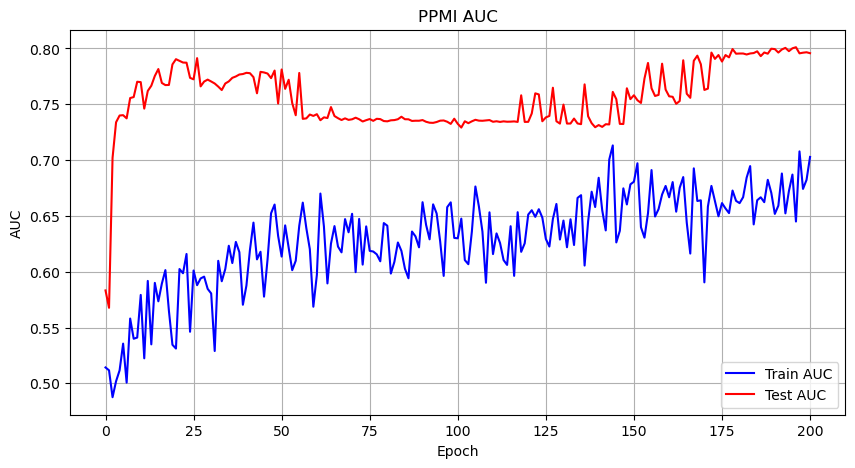

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("PPMI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

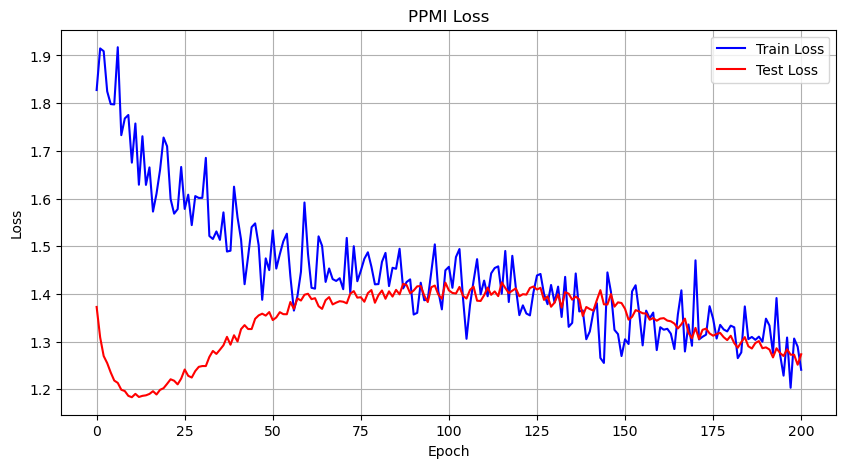

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()